# Эффективность маркетинговых каналов и атрибуция

**Автор:** Мария Васильева  
**Контакт:** mnivasilyeva@gmail.com · Telegram: @MNVasilyeva

## Контекст

Онлайн-магазин привлекает пользователей через платный поиск, рекламу в социальных сетях, email-рассылки, реферальную программу и органический трафик. Для планирования маркетингового бюджета необходимо сопоставить охват и оплаченные заказы с расходами и атрибутированной выручкой каждого канала.

## Цель проекта

Оценить эффективность каналов привлечения и подготовить рекомендации для маркетинговой команды на основе пользовательской активности, оплаченных заказов и маркетинговых расходов.

## Правила расчёта

- охват канала — количество уникальных пользователей, у которых была хотя бы одна сессия из этого канала;
- платящие пользователи, заказы и выручка атрибутируются каналу самой ранней зафиксированной сессии;
- в расчётах заказов и выручки учитываются только заказы со статусом `paid`;
- если пользователь совершил несколько оплаченных заказов, учитываются все такие заказы;
- платящим считается пользователь хотя бы с одним оплаченным заказом;
- расходы агрегируются до уровня маркетингового канала;
- для каналов с нулевыми расходами CAC и ROMI не рассчитываются.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", palette="rocket")

# 1. Исследование и подготовка данных

In [5]:
# Загружаю данные о маркетинговых расходах, заказах и сессиях
mrkt = pd.read_csv("marketing_spend.csv")
orders = pd.read_csv("orders.csv")
sessions = pd.read_csv("sessions.csv")


In [6]:
# Проверяю структуру и типы данных
mrkt.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   spend_id     100000 non-null  str    
 1   spend_date   100000 non-null  str    
 2   channel      100000 non-null  str    
 3   campaign_id  100000 non-null  str    
 4   ad_group_id  100000 non-null  str    
 5   spend        100000 non-null  float64
dtypes: float64(1), str(5)
memory usage: 4.6 MB


In [7]:
mrkt["channel"].unique()
# В данных представлены пять маркетинговых каналов


<StringArray>
['paid_search', 'paid_social', 'email', 'referral', 'organic']
Length: 5, dtype: str

In [8]:
print(orders.info())
print("\n")
print("Пустые значения отсутствуют")
print("Количество заказов:", orders["order_id"].nunique())
print("Количество уникальных пользователей в таблице заказов:", orders["user_id"].nunique())
print("\nУникальные статусы заказов:", orders["status"].unique())

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   order_id    120000 non-null  str  
 1   user_id     120000 non-null  str  
 2   order_date  120000 non-null  str  
 3   status      120000 non-null  str  
 4   revenue     120000 non-null  int64
dtypes: int64(1), str(4)
memory usage: 4.6 MB
None


Пустые значения отсутствуют
Количество заказов: 120000
Количество уникальных пользователей в таблице заказов: 64379

Уникальные статусы заказов: <StringArray>
['cancelled', 'paid', 'refunded']
Length: 3, dtype: str


In [9]:
print(sessions.info())
print("Пустые значения отсутствуют")
print("\n")
print("Количество уникальных пользователей в таблице сессий:", sessions["user_id"].nunique())
print("Количество уникальных сессий:", sessions["session_id"].nunique())
print("\nТипы устройств:", sessions["device"].unique())

<class 'pandas.DataFrame'>
RangeIndex: 160000 entries, 0 to 159999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   session_id    160000 non-null  str  
 1   user_id       160000 non-null  str  
 2   session_date  160000 non-null  str  
 3   channel       160000 non-null  str  
 4   device        160000 non-null  str  
dtypes: str(5)
memory usage: 6.1 MB
None
Пустые значения отсутствуют


Количество уникальных пользователей в таблице сессий: 85000
Количество уникальных сессий: 160000

Типы устройств: <StringArray>
['tablet', 'mobile', 'desktop']
Length: 3, dtype: str


In [10]:
# Преобразую поля с датами в формат datetime 
mrkt["spend_date"] = pd.to_datetime(mrkt["spend_date"])
orders["order_date"]=pd.to_datetime(orders["order_date"])
sessions["session_date"]=pd.to_datetime(sessions["session_date"])

In [11]:
# Оставляю только успешно оплаченные заказы
orders = orders[orders["status"]=="paid"]
print("Количество успешно оплаченных заказов:", orders.shape)
orders_per_users = orders.groupby("user_id").agg(orders_cnt=("order_id","nunique")).sort_values("orders_cnt", ascending=False) # Некоторые пользователи совершили более одного заказа
orders_per_users
# Большинство пользователей совершили один заказ, максимальное количество — шесть

Количество успешно оплаченных заказов: (56345, 5)


,orders_cnt
user_id,
u059007,6
u044665,6
u069539,6
u037948,6
u076411,5
...,...
u033888,1
u033886,1
u033882,1


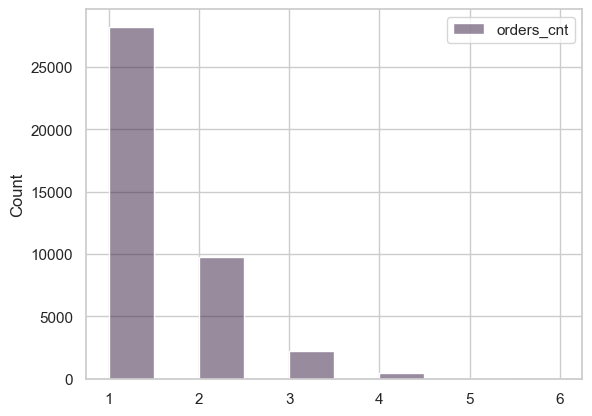

In [12]:
# fig, ax = plt.subplots(figsize=(4,6))
sns.histplot(orders_per_users, bins=10 );

In [13]:
channels_per_users = sessions.groupby("user_id").agg(channels=("channel", "nunique")).sort_values("channels", ascending=False)
channels_per_users
# Большинство пользователей взаимодействовали с одним каналом, отдельные пользователи — с четырьмя

,channels
user_id,
u064823,4
u061700,4
u046115,4
u078509,4
u007895,4
...,...
u031081,1
u031080,1
u031079,1


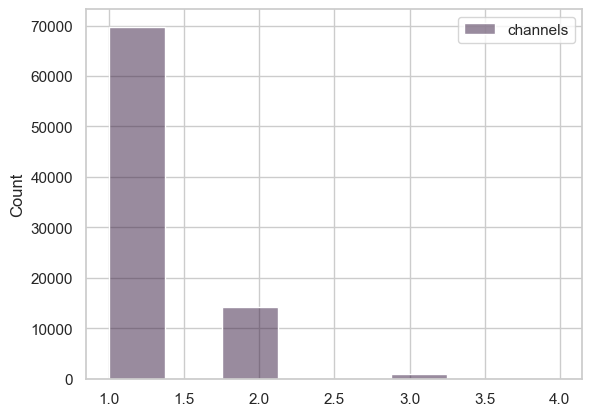

In [14]:
# fig, ax = plt.subplots(figsize=(3,10))
sns.histplot(channels_per_users, bins=8 );

In [15]:
sessions.groupby(["user_id", "channel"]).agg(count=("session_date", "count")).sort_values(by=["user_id","channel","count"], ascending=[True, True, False])
# Пользователи могли взаимодействовать с несколькими каналами и возвращаться через один и тот же канал несколько раз


count
user_id channel           
u000001 email            1
u000002 email            1
u000003 paid_social      1
u000004 paid_social      1
u000005 referral         3
...                    ...
u084997 paid_social      1
        referral         1
u084998 paid_search      2
u084999 paid_social      1
u085000 paid_social      1

[101371 rows x 1 columns]

# 2. Расчёт показателей по маркетинговым каналам

На этом этапе рассчитываются охват уникальных пользователей, количество оплаченных заказов, конверсия в платящего пользователя, выручка и средний чек.

Для сопоставимости показателей используется first-touch attribution: пользователь и его заказы относятся к каналу первой зафиксированной сессии.


## Охват канала: уникальные пользователи

In [16]:
print("Количество уникальных пользователей по каналам:")
unique_users_per_channel = sessions.groupby("channel").agg(unique_users = ("user_id", "nunique")).sort_values("unique_users", ascending=False)
unique_users_per_channel

Количество уникальных пользователей по каналам:


,unique_users
channel,
paid_search,31758
organic,22616
paid_social,21798
referral,13133
email,12066


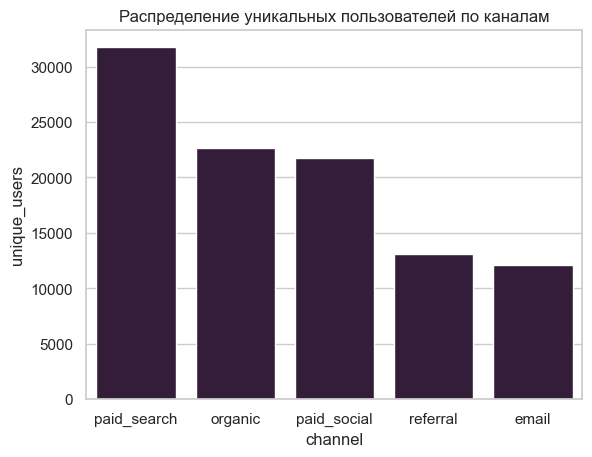

In [17]:
sns.barplot(unique_users_per_channel, x="channel",y="unique_users")
plt.title("Уникальные пользователи по каналам");

## Количество оплаченных заказов

In [18]:
# Объединяю оплаченные заказы с данными о пользовательских сессиях
orders_per_channels = pd.merge(sessions, orders, on="user_id", how='right')
orders_per_channels.sort_values(by=["user_id", "order_id","session_date"])


,session_id,user_id,session_date,channel,device,order_id,order_date,status,revenue
17722,s0026899,u000001,2026-01-27,email,mobile,o0092652,2026-02-24,paid,1160
4333,s0005722,u000002,2026-01-07,email,mobile,o0023549,2026-01-29,paid,970
35985,s0005722,u000002,2026-01-07,email,mobile,o0060318,2026-03-16,paid,1250
86681,s0094276,u000005,2026-03-16,referral,mobile,o0007187,2026-04-19,paid,2520
86682,s0101349,u000005,2026-03-20,referral,desktop,o0007187,2026-04-19,paid,2520
...,...,...,...,...,...,...,...,...,...
75703,s0124891,u084995,2026-03-31,paid_search,mobile,o0046526,2026-04-12,paid,2850
75704,s0124892,u084995,2026-03-31,paid_social,mobile,o0046526,2026-04-12,paid,2850
91203,s0023518,u084998,2026-01-23,paid_search,desktop,o0099119,2026-04-21,paid,2370
91204,s0084232,u084998,2026-03-09,paid_search,mobile,o0099119,2026-04-21,paid,2370


In [19]:
# Проверяю правило атрибуции на примере: заказ o0040888 относится к email — каналу самой ранней сессии
orders_per_channels[orders_per_channels['order_id']=="o0040888"].sort_values("session_date")


,session_id,user_id,session_date,channel,device,order_id,order_date,status,revenue
50146,s0026673,u068855,2026-01-26,email,mobile,o0040888,2026-03-27,paid,960
50147,s0071378,u068855,2026-03-01,organic,mobile,o0040888,2026-03-27,paid,960
50148,s0077482,u068855,2026-03-05,paid_social,mobile,o0040888,2026-03-27,paid,960
50149,s0082277,u068855,2026-03-08,email,desktop,o0040888,2026-03-27,paid,960
50150,s0114325,u068855,2026-03-26,referral,mobile,o0040888,2026-03-27,paid,960
50151,s0143445,u068855,2026-04-16,email,mobile,o0040888,2026-03-27,paid,960


In [20]:
print("Количество оплаченных заказов по каналам")
orders_cnt_per_channels = orders_per_channels.sort_values(
    ["order_id", "session_date"]
    ).drop_duplicates("order_id", keep='first'  # Оставляю первое касание для каждого заказа
                      ).groupby("channel"       # Группирую по каналу
                                ).agg(orders_cnt=("order_id","nunique")).sort_values("orders_cnt", ascending=False) # Считаю уникальные заказы и сортирую результат
orders_cnt_per_channels

Количество оплаченных заказов по каналам


,orders_cnt
channel,
paid_search,21463
organic,13220
referral,7790
paid_social,7211
email,6661


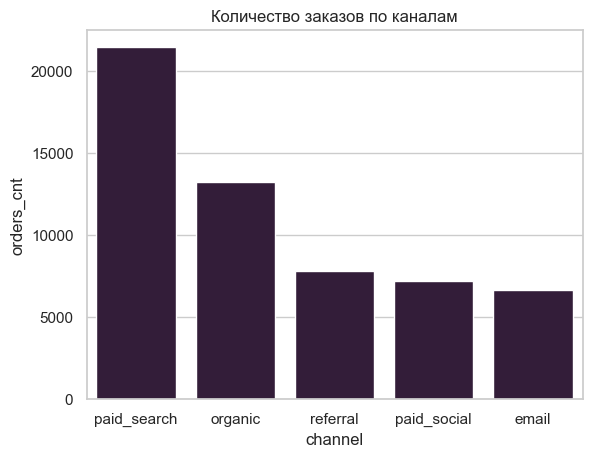

In [21]:
sns.barplot(orders_cnt_per_channels, x="channel",y="orders_cnt")
plt.title("Количество оплаченных заказов по каналам");

## Отношение first-touch платящих пользователей к охвату канала

В числителе используются платящие пользователи, атрибутированные по первому касанию. В знаменателе — все пользователи, взаимодействовавшие с каналом. Поэтому показатель используется как сравнительный диагностический коэффициент, а не как строгая когортная конверсия.


In [22]:
# Рассчитываю количество всех пользователей по каналам для знаменателя конверсии
all_users = sessions.groupby("channel").agg(all_users=("user_id","nunique"))

In [23]:
# Проверяю распределение количества оплаченных заказов на пользователя
orders.groupby("user_id")["order_id"].count().sort_values(ascending=False)

user_id
u059007    6
u044665    6
u069539    6
u037948    6
u076411    5
          ..
u033888    1
u033886    1
u033882    1
u033880    1
u085000    1
Name: order_id, Length: 40659, dtype: int64

In [24]:
orders_per_channels[orders_per_channels["user_id"]=="u037948"].sort_values(["order_id", "session_date"])
# Для этого пользователя первой была сессия из organic, поэтому все его заказы атрибутируются organic, несмотря на последующие визиты из paid search.


,session_id,user_id,session_date,channel,device,order_id,order_date,status,revenue
95684,s0005177,u037948,2026-01-06,organic,mobile,o0067886,2026-04-24,paid,1460
95685,s0100323,u037948,2026-03-19,paid_search,mobile,o0067886,2026-04-24,paid,1460
95686,s0155829,u037948,2026-04-27,organic,desktop,o0067886,2026-04-24,paid,1460
21399,s0005177,u037948,2026-01-06,organic,mobile,o0072584,2026-03-01,paid,1340
21400,s0100323,u037948,2026-03-19,paid_search,mobile,o0072584,2026-03-01,paid,1340
21401,s0155829,u037948,2026-04-27,organic,desktop,o0072584,2026-03-01,paid,1340
1749,s0005177,u037948,2026-01-06,organic,mobile,o0095759,2026-01-18,paid,1940
1750,s0100323,u037948,2026-03-19,paid_search,mobile,o0095759,2026-01-18,paid,1940
1751,s0155829,u037948,2026-04-27,organic,desktop,o0095759,2026-01-18,paid,1940
5849,s0005177,u037948,2026-01-06,organic,mobile,o0097634,2026-02-02,paid,1370


In [25]:
# Рассчитываю числитель конверсии: платящий пользователь относится к каналу своей первой сессии
paid_users = orders_per_channels.sort_values(
    ["user_id", "session_date"]
    ).drop_duplicates("user_id", keep='first'  # Оставляю первое касание для каждого пользователя
                      ).groupby("channel"       # Группирую по каналу
                                ).agg(paid_users=("user_id","nunique")).sort_values("paid_users", ascending=False) # Считаю платящих пользователей и сортирую результат
paid_users

,paid_users
channel,
paid_search,15288
organic,9605
paid_social,5923
referral,5276
email,4567


In [26]:
print("Конверсия в платящего пользователя")
conversion = pd.merge(all_users, paid_users, on="channel")
conversion["conversion"] = round(conversion["paid_users"]*100/conversion["all_users"], 2)
conversion.sort_values("conversion", ascending=False)

Отношение first-touch платящих пользователей к охвату канала


,all_users,paid_users,conversion
channel,,,
paid_search,31758,15288,48.14
organic,22616,9605,42.47
referral,13133,5276,40.17
email,12066,4567,37.85
paid_social,21798,5923,27.17


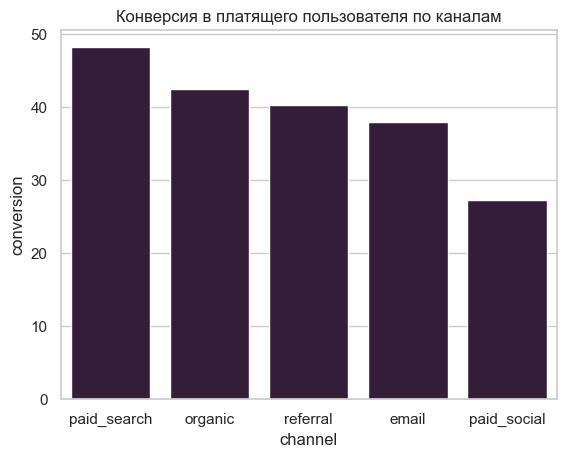

In [27]:
sns.barplot(conversion.sort_values("conversion", ascending=False), x="channel",y="conversion")
plt.title("Конверсия в платящего пользователя по каналам");

## Выручка по оплаченным заказам

In [28]:
# Выручка — сумма revenue по всем уникальным оплаченным заказам в разрезе канала
print("Выручка по каналам")
total_revenue = orders_per_channels.sort_values(
    ["order_id", "session_date"]
    ).drop_duplicates("order_id", keep='first'  # Оставляю первое касание для каждого заказа
                      ).groupby("channel"       # Группирую по каналу
                                ).agg(total_revenue=("revenue","sum")).sort_values("total_revenue", ascending=False) # Суммирую выручку и сортирую результат
total_revenue

Выручка по каналам


,total_revenue
channel,
paid_search,35121030
referral,20260630
organic,18053060
paid_social,8028800
email,6306120


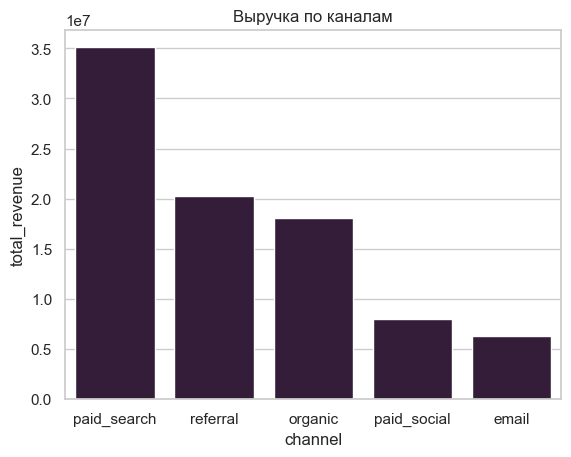

In [29]:
sns.barplot(total_revenue, x="channel",y="total_revenue")
plt.title("Выручка по каналам");

## Средний чек по оплаченным заказам

In [30]:
# AOV (Average Order Value) — средний чек
print("Средний чек по каналам")
orders_per_channels.sort_values(
    ["order_id", "session_date"]
    ).drop_duplicates("order_id", keep='first'  # Оставляю первое касание для каждого заказа
                      ).groupby("channel"       # Группирую по каналу
                                ).agg(aov=("revenue",lambda x: round(x.mean(), 2))).sort_values("aov", ascending=False) # Рассчитываю средний чек и сортирую результат

Средний чек по каналам


,aov
channel,
referral,2600.85
paid_search,1636.35
organic,1365.59
paid_social,1113.41
email,946.72


# 3. Эффективность маркетинговых инвестиций

## CAC — стоимость привлечения платящего пользователя

```text
CAC = маркетинговые расходы / количество платящих пользователей
```


In [31]:
mrkt.sample(3)

,spend_id,spend_date,channel,campaign_id,ad_group_id,spend
29295,m0029296,2026-03-27,email,ema_c025,ag007,193.30
53246,m0053247,2026-01-12,paid_search,pai_c045,ag004,1108.57
54040,m0054041,2026-01-23,email,ema_c028,ag017,228.05


In [32]:
# Агрегирую маркетинговые расходы по каналам
total_spend = mrkt.groupby("channel").agg(total_spend=("spend", "sum")).sort_values("total_spend", ascending=False)
CAC = pd.merge(total_spend, paid_users, on = "channel")
CAC["CAC"] = np.where(CAC["total_spend"]>0, round(CAC["total_spend"] / CAC["paid_users"],2), np.nan)
CAC.sort_values("CAC", ascending=False)

,total_spend,paid_users,CAC
channel,,,
paid_social,13842758.62,5923,2337.12
paid_search,28787729.51,15288,1883.03
referral,7108992.98,5276,1347.42
email,3821890.91,4567,836.85
organic,0.00,9605,NaN


Самым дорогим платным каналом оказалась реклама в социальных сетях: стоимость привлечения одного платящего пользователя составила **2 337,12**.

Платный поиск занимает второе место по CAC (**1 883,03**), но привлекает примерно в 2,6 раза больше платящих пользователей, чем социальные сети.

Органический трафик не имеет прямых маркетинговых расходов и при этом занимает второе место по количеству платящих пользователей.


## ROMI — окупаемость маркетинговых инвестиций

```text
ROMI = (выручка − маркетинговые расходы) / маркетинговые расходы
```


In [33]:
ROMI = pd.merge(total_revenue, CAC, on="channel")
ROMI = ROMI[["total_revenue","total_spend"]]
ROMI["ROMI"] = np.where(ROMI["total_spend"]>0, round((ROMI["total_revenue"] - ROMI["total_spend"]) / ROMI["total_spend"],2), np.nan)
ROMI.sort_values("ROMI", ascending=False)

,total_revenue,total_spend,ROMI
channel,,,
referral,20260630,7108992.98,1.85
email,6306120,3821890.91,0.65
paid_search,35121030,28787729.51,0.22
paid_social,8028800,13842758.62,-0.42
organic,18053060,0.00,NaN


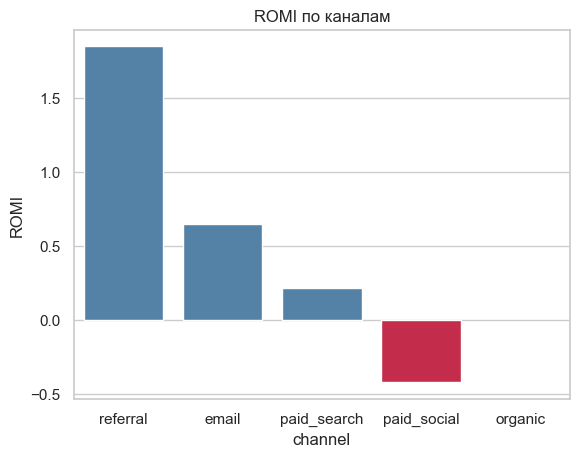

In [34]:
colors = ["crimson" if x < 0 else "steelblue" for x in ROMI.sort_values("ROMI", ascending=False)["ROMI"]]

sns.barplot(ROMI.sort_values("ROMI", ascending=False), x="channel",y="ROMI", palette=colors)
plt.title("ROMI по каналам");

ROMI показывает, сколько дополнительной выручки сверх вложенного бюджета приносит каждый канал.

- **Referral** — наиболее окупаемый канал: ROMI составляет **1,85**, то есть каждый вложенный рубль приносит 1,85 рубля выручки сверх маркетинговых затрат.
- **Email** демонстрирует положительную окупаемость (**0,65**) при сравнительно низком CAC.
- **Paid search** также окупается, но его ROMI заметно ниже (**0,22**).
- **Paid social** имеет отрицательный ROMI (**−0,42**): расходы превышают атрибутированную выручку.
- Для **organic** ROMI не рассчитывается, поскольку прямые расходы равны нулю.


# 4. Выводы и рекомендации

1. **Реферальная программа — наиболее эффективный платный канал.** Она сочетает максимальный ROMI (**1,85**), сравнительно низкий CAC (**1 347,42**) и самый высокий средний чек (**2 600,85**). Канал целесообразно масштабировать, предварительно проверив, сохраняется ли эффективность при увеличении бюджета.

2. **Paid social требует пересмотра.** Канал имеет самый высокий CAC (**2 337,12**), самую низкую конверсию в платящего пользователя (**27,17%**) и отрицательный ROMI (**−0,42**). Следующий шаг — анализ эффективности на уровне кампаний и рекламных групп, а также проверка качества привлекаемой аудитории.

3. **Email — недорогой и окупаемый канал.** Несмотря на относительно небольшой объём выручки, он показывает низкий CAC (**836,85**) и положительный ROMI (**0,65**). Можно тестировать расширение охвата и улучшение сценариев коммуникации.

4. **Paid search обеспечивает основной масштаб, но работает с небольшой маржой относительно расходов.** Канал приводит больше всего платящих пользователей и формирует максимальную выручку, однако ROMI составляет только **0,22**. Для повышения эффективности требуется оптимизация кампаний и ключевых запросов.

5. **Результаты зависят от выбранной модели атрибуции.** Пользователи взаимодействуют с несколькими каналами до покупки, поэтому first-touch attribution может переоценивать каналы первого знакомства и недооценивать каналы, расположенные ближе к заказу. Для проверки устойчивости выводов стоит сравнить результаты с last-touch и многоканальной атрибуцией.
